In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")
df = pd.read_csv('/content/sample_data/ecommerce_customer_sales.csv')
df.head()



,Order_ID,Customer_ID,Order Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,5/29/2023,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,10/12/2023,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,12/5/2023,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,5/11/2023,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,6/16/2023,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


<Figure size 800x500 with 0 Axes>

## Understand Data

In [3]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Order Date                17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000,17049.000000
mean,34.945745,447.901689,3.011379,69.788135,1277.438711,14.535633,9.003109,6.503607,3.899408
std,11.046855,722.319705,1.417027,240.704662,2358.436375,2.925524,2.259954,3.488787,1.128803
min,18.000000,5.050000,1.000000,0.000000,6.210000,4.000000,1.000000,1.000000,1.000000
25%,26.000000,73.260000,2.000000,0.000000,172.970000,13.000000,7.000000,4.000000,3.000000
50%,35.000000,174.680000,3.000000,0.000000,455.850000,15.000000,9.000000,6.000000,4.000000
75%,42.000000,494.570000,4.000000,32.710000,1267.750000,17.000000,11.000000,8.000000,5.000000
max,75.000000,7900.010000,5.000000,6538.290000,37852.050000,26.000000,18.000000,25.000000,5.000000


# Data Cleaning

In [6]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])


# Feature Engineering

In [7]:
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Year'] = df['Order Date'].dt.year

# If Total_Amount not correct, recalc
df['Revenue'] = df['Unit_Price'] * df['Quantity'] - df['Discount_Amount']


# Sales Analysis
Monthly Revenue Trend

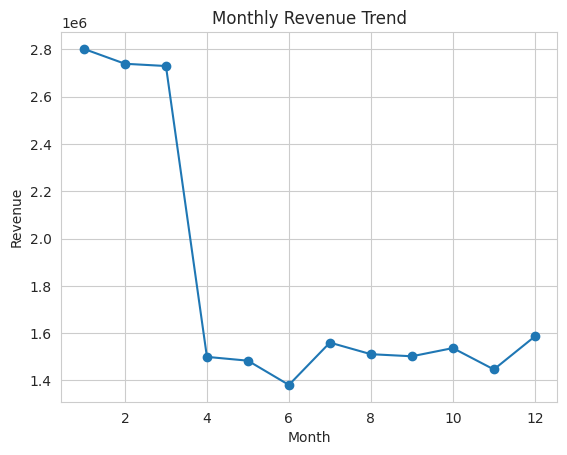

In [8]:
monthly_sales = df.groupby('Order_Month')['Revenue'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()


#Top Product Categories

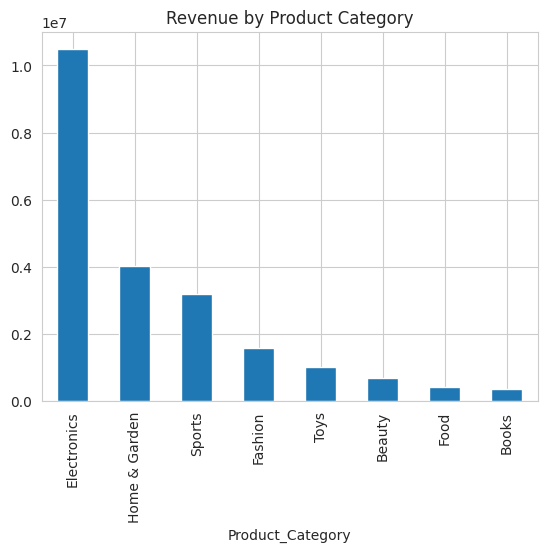

In [9]:
top_cat = df.groupby('Product_Category')['Revenue'].sum().sort_values(ascending=False)

top_cat.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.show()


# Customer Behavior
Returning vs New Customers

In [10]:
df.groupby('Is_Returning_Customer')['Revenue'].mean()


,Revenue
Is_Returning_Customer,
False,1287.727428
True,1276.063599


#Age Group Contribution

In [11]:
df.groupby('Age')['Revenue'].sum().head(10)


,Revenue
Age,
18,2084936.48
19,303335.70
20,335342.18
21,353493.45
22,376269.33
23,537258.11
24,472230.90
25,506151.91
26,545324.21


#Gender Analysis

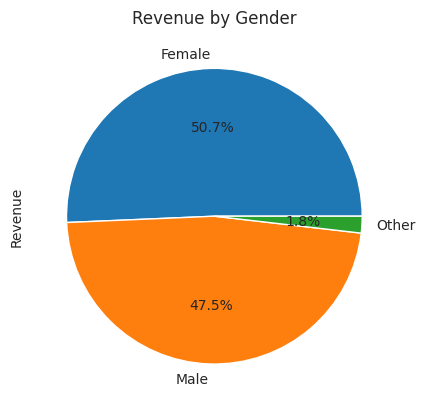

In [12]:
gender_sales = df.groupby('Gender')['Revenue'].sum()

gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Revenue by Gender')
plt.show()


#Discount Impact
Higher discounts do not always increase revenue.

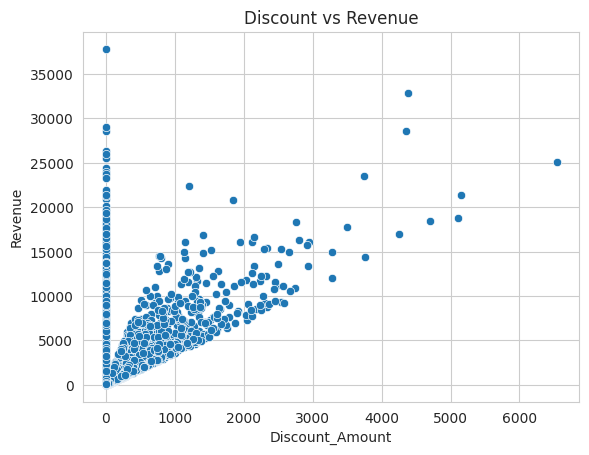

In [13]:
sns.scatterplot(x='Discount_Amount', y='Revenue', data=df)
plt.title('Discount vs Revenue')
plt.show()


#Session Behavior

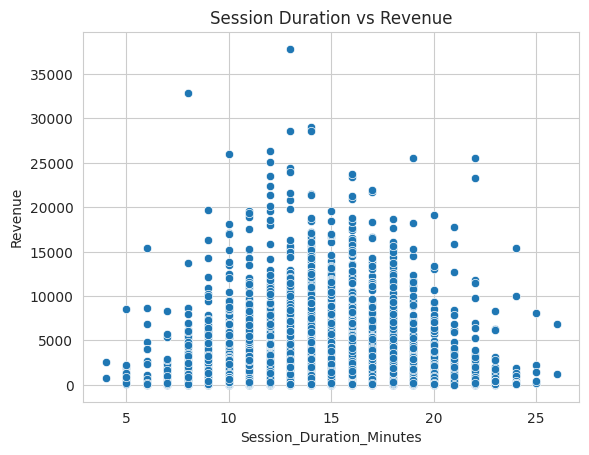

In [14]:
sns.scatterplot(x='Session_Duration_Minutes', y='Revenue', data=df)
plt.title('Session Duration vs Revenue')
plt.show()


#Delivery & Rating
Faster delivery → better ratings.

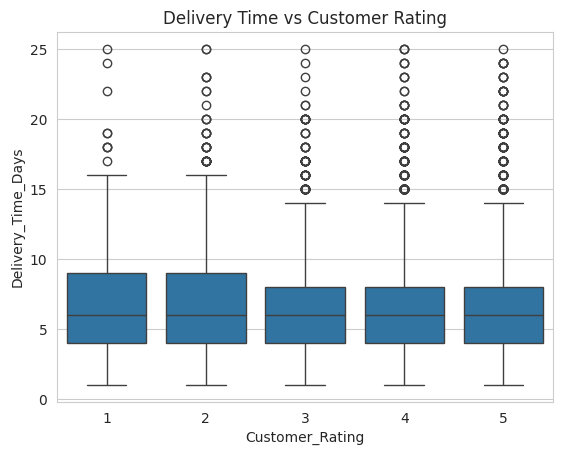

In [15]:
sns.boxplot(x='Customer_Rating', y='Delivery_Time_Days', data=df)
plt.title('Delivery Time vs Customer Rating')
plt.show()


#Payment Method Analysis

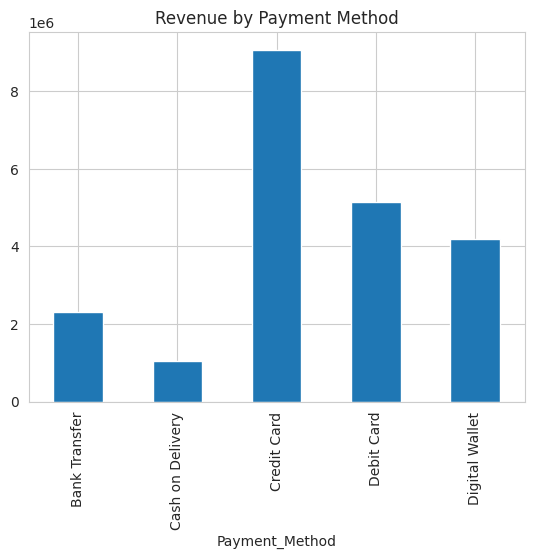

In [16]:
payment = df.groupby('Payment_Method')['Revenue'].sum()

payment.plot(kind='bar')
plt.title('Revenue by Payment Method')
plt.show()


#Key Metrics (KPI Calculation)

In [17]:
total_revenue = df['Revenue'].sum()
avg_order_value = df['Revenue'].mean()
repeat_customer_rate = df['Is_Returning_Customer'].mean() * 100

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)
print("Repeat Customer %:", repeat_customer_rate)


Total Revenue: 21779052.59
Average Order Value: 1277.4387113613702
Repeat Customer %: 88.210452225937


#Business Insights
Insights Example

Returning customers spend more than new customers.

Faster delivery improves ratings.

Discounts reduce profit after certain limit.

Mobile users have higher session duration.

Certain age groups drive more revenue.